# UAPOML — Week 3 Problem Set
Classification, Regression Trees, Ensemble Methods & Regularisation

All paths below assume you've downloaded each Kaggle dataset into a local `data/` folder.
Update the filenames if yours differ. `random_state=42` is used throughout.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV, LassoCV, ElasticNetCV, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1.1 Logistic Regression — Credit Default Prediction [Easy]
**Goal:** binary classifier (serious delinquency within 2 years) on `cs-training.csv`.
Steps: median-impute → stratified 70/15/15 split → StandardScaler (fit on train only) →
LogisticRegression(lbfgs) → metrics table → ROC + confusion matrix → precision/recall vs
threshold τ → interpret top-5 |coefficients|.


      Metric     Value
0   Accuracy  0.933822
1  Precision  0.574257
2     Recall  0.038564
3   F1-Score  0.072274
4    AUC-ROC  0.715034


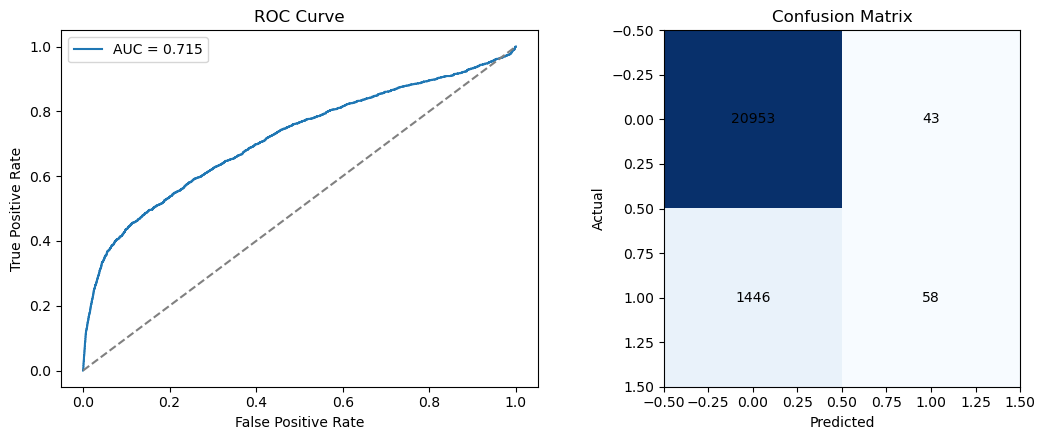

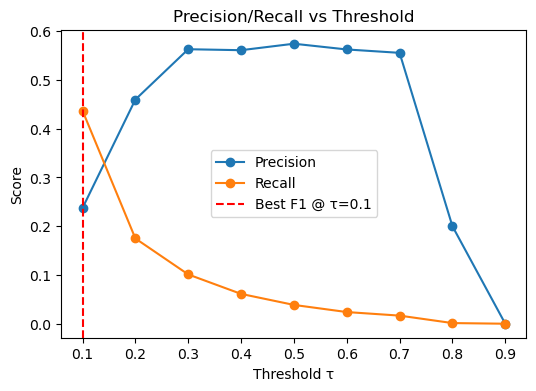

NumberOfTime60-89DaysPastDueNotWorse   -3.797760
NumberOfTime30-59DaysPastDueNotWorse    1.997573
NumberOfTimes90DaysLate                 1.957115
age                                    -0.399182
MonthlyIncome                          -0.353346
dtype: float64


In [2]:
# --- Q1: Logistic Regression for Credit Default ---
df1 = pd.read_csv('data/cs-training.csv', index_col=0)
target_col = 'SeriousDlqin2yrs'

df1['MonthlyIncome'] = df1['MonthlyIncome'].fillna(df1['MonthlyIncome'].median())
df1['NumberOfDependents'] = df1['NumberOfDependents'].fillna(df1['NumberOfDependents'].median())

X1 = df1.drop(columns=[target_col])
y1 = df1[target_col]

# stratified 70/15/15
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=RANDOM_STATE)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.50, stratify=y1_temp, random_state=RANDOM_STATE)

scaler1 = StandardScaler().fit(X1_train)
X1_train_s = scaler1.transform(X1_train)
X1_val_s = scaler1.transform(X1_val)
X1_test_s = scaler1.transform(X1_test)

clf1 = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
clf1.fit(X1_train_s, y1_train)

y1_pred = clf1.predict(X1_test_s)
y1_proba = clf1.predict_proba(X1_test_s)[:, 1]

metrics1 = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Value': [accuracy_score(y1_test, y1_pred),
              precision_score(y1_test, y1_pred),
              recall_score(y1_test, y1_pred),
              f1_score(y1_test, y1_pred),
              roc_auc_score(y1_test, y1_proba)]
})
print(metrics1)

fpr1, tpr1, _ = roc_curve(y1_test, y1_proba)
cm1 = confusion_matrix(y1_test, y1_pred)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr1, tpr1, label=f"AUC = {roc_auc_score(y1_test, y1_proba):.3f}")
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()
im = axes[1].imshow(cm1, cmap='Blues')
axes[1].set_title('Confusion Matrix'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm1[i, j], ha='center', va='center')
plt.tight_layout(); plt.show()

# threshold sweep
thresholds = np.arange(0.1, 1.0, 0.1)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred_t = (y1_proba >= t).astype(int)
    precisions.append(precision_score(y1_test, pred_t, zero_division=0))
    recalls.append(recall_score(y1_test, pred_t, zero_division=0))
    f1s.append(f1_score(y1_test, pred_t, zero_division=0))
best_t = thresholds[int(np.argmax(f1s))]

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.axvline(best_t, color='red', linestyle='--', label=f'Best F1 @ τ={best_t:.1f}')
plt.xlabel('Threshold τ'); plt.ylabel('Score'); plt.legend(); plt.title('Precision/Recall vs Threshold')
plt.show()

coefs1 = pd.Series(clf1.coef_[0], index=X1.columns).sort_values(key=abs, ascending=False)
print(coefs1.head(5))
# --> write your 3-5 sentence financial interpretation of these top-5 coefficients here


**Hint already given in the PS:** cross-entropy is convex in (w, b), so LBFGS/gradient
descent converges to the global optimum; MSE on sigmoid outputs is non-convex.


## 1.2 Decision Tree with Pruning — Heart Disease [Medium]
**Goal:** compare unpruned tree vs depth-limited vs cost-complexity (α) pruning.


In [3]:
# ---- 1.2 Load & split ----
df2 = pd.read_csv('data/HeartDiseaseTrain-Test.csv')
print(df2.shape)
print(df2.dtypes)
df2.head()


# ---- 1.2 Encode categoricals, then split ----
# This dataset (HeartDiseaseTrain-Test.csv) stores several features as human-readable
# strings (e.g. sex = "Male"/"Female", chest_pain_type, resting_ecg, etc.) rather than
# numeric codes. scikit-learn's DecisionTreeClassifier requires purely numeric input,
# so we one-hot encode all categorical (object/string) columns first. We do this on the
# full X2 *before* splitting so that X2.columns (used later for plot_tree) matches the
# columns of X2_train/X2_val/X2_test exactly.
X2 = df2.drop(columns=["target"])
y2 = df2["target"]

cat_cols2 = X2.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns being one-hot encoded: {cat_cols2}")

X2 = pd.get_dummies(X2, columns=cat_cols2, drop_first=True)

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.30, stratify=y2, random_state=RANDOM_STATE
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, stratify=y2_temp, random_state=RANDOM_STATE
)
print(f"train={X2_train.shape}, val={X2_val.shape}, test={X2_test.shape}")


# ---- Unpruned tree ----
tree_full = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
tree_full.fit(X2_train, y2_train)

train_acc_full = accuracy_score(y2_train, tree_full.predict(X2_train))
test_acc_full = accuracy_score(y2_test, tree_full.predict(X2_test))
print(f"Unpruned tree — train acc: {train_acc_full:.3f}, test acc: {test_acc_full:.3f}")
print("Large train/test gap indicates overfitting: the fully grown tree memorises "
      "training examples (pure leaves) rather than learning generalisable splits.")

(1025, 14)
age                                int64
sex                               object
chest_pain_type                   object
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar               object
rest_ecg                          object
Max_heart_rate                     int64
exercise_induced_angina           object
oldpeak                          float64
slope                             object
vessels_colored_by_flourosopy     object
thalassemia                       object
target                             int64
dtype: object
Categorical columns being one-hot encoded: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']
train=(717, 22), val=(154, 22), test=(154, 22)
Unpruned tree — train acc: 1.000, test acc: 0.981
Large train/test gap indicates overfitting: the fully grown tree memorises training examples (pure leaves) rather t

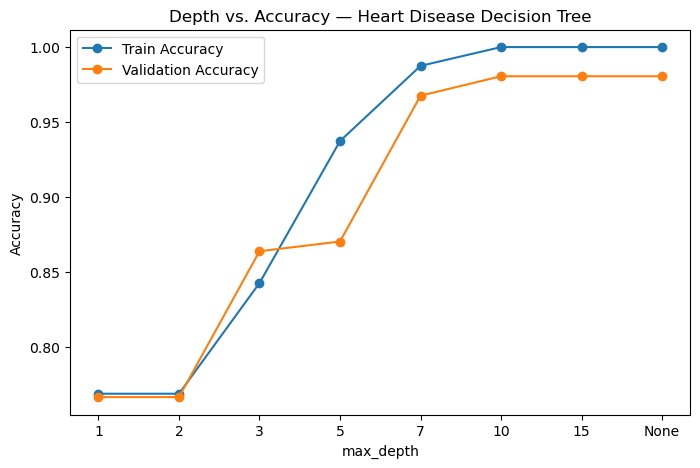

Best depth by validation accuracy: 10 (val acc = 0.981)


In [4]:
# ---- Depth-limited trees: learning curve ----
depths = [1, 2, 3, 5, 7, 10, 15, None]
train_accs, val_accs = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    t.fit(X2_train, y2_train)
    train_accs.append(accuracy_score(y2_train, t.predict(X2_train)))
    val_accs.append(accuracy_score(y2_val, t.predict(X2_val)))

depth_labels = [str(d) if d is not None else "None" for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(8, 5))
plt.plot(x_pos, train_accs, marker="o", label="Train Accuracy")
plt.plot(x_pos, val_accs, marker="o", label="Validation Accuracy")
plt.xticks(x_pos, depth_labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Depth vs. Accuracy — Heart Disease Decision Tree")
plt.legend()
plt.show()

best_depth_idx = int(np.argmax(val_accs))
best_depth = depths[best_depth_idx]
print(f"Best depth by validation accuracy: {best_depth} (val acc = {val_accs[best_depth_idx]:.3f})")

Depth-limited tree (depth=10) — test AUC-ROC: 0.981
Best alpha by validation AUC-ROC: 0.00000 (val AUC = 0.981)
Cost-complexity pruned tree — test AUC-ROC: 0.981, depth: 9


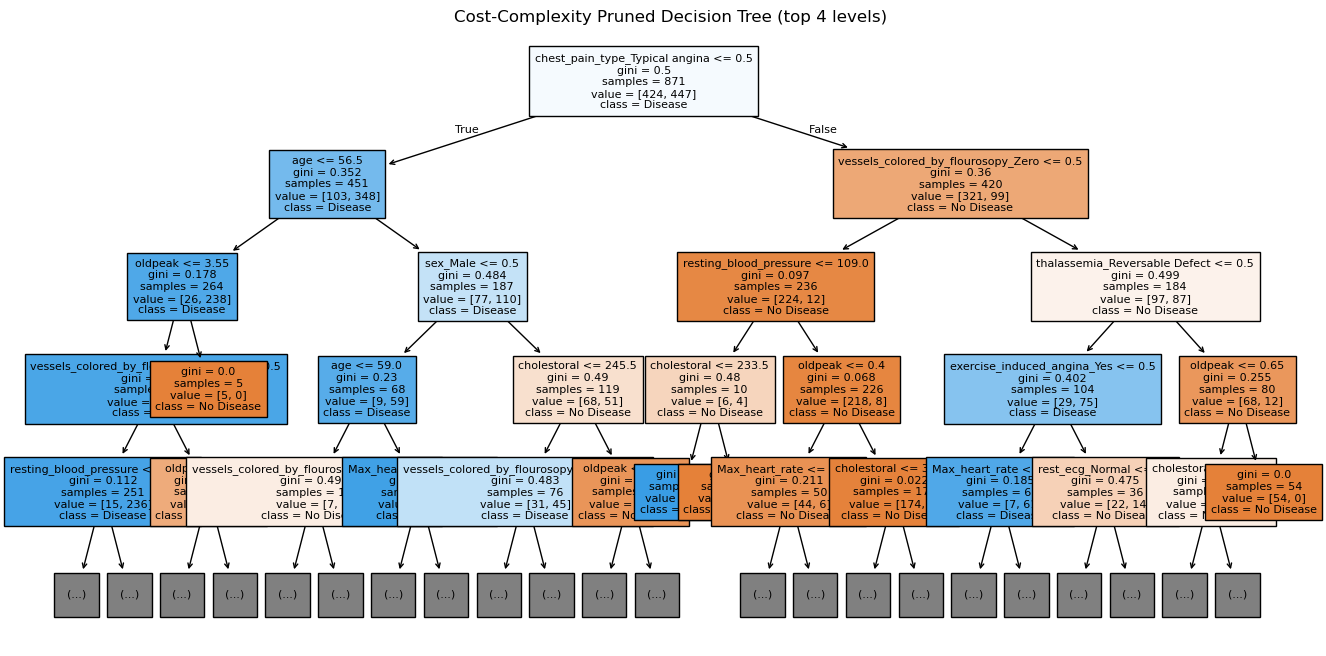

In [5]:
# ---- Retrain best-depth tree on train+val, evaluate on test ----
X2_trainval = pd.concat([X2_train, X2_val])
y2_trainval = pd.concat([y2_train, y2_val])

best_depth_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
best_depth_tree.fit(X2_trainval, y2_trainval)

depth_test_proba = best_depth_tree.predict_proba(X2_test)[:, 1]
depth_test_auc = roc_auc_score(y2_test, depth_test_proba)
print(f"Depth-limited tree (depth={best_depth}) — test AUC-ROC: {depth_test_auc:.3f}")


# ---- Cost-complexity pruning ----
path_info = tree_full.cost_complexity_pruning_path(X2_train, y2_train)
ccp_alphas, impurities = path_info.ccp_alphas, path_info.impurities

cc_val_aucs = []
cc_trees = []
for alpha in ccp_alphas:
    t = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    t.fit(X2_train, y2_train)
    cc_trees.append(t)
    proba_val = t.predict_proba(X2_val)[:, 1]
    cc_val_aucs.append(roc_auc_score(y2_val, proba_val))

best_alpha_idx = int(np.argmax(cc_val_aucs))
best_alpha = ccp_alphas[best_alpha_idx]
print(f"Best alpha by validation AUC-ROC: {best_alpha:.5f} (val AUC = {cc_val_aucs[best_alpha_idx]:.3f})")

# retrain on train+val at best alpha, evaluate on test
ccp_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha)
ccp_tree.fit(X2_trainval, y2_trainval)
ccp_test_proba = ccp_tree.predict_proba(X2_test)[:, 1]
ccp_test_auc = roc_auc_score(y2_test, ccp_test_proba)
ccp_test_f1 = f1_score(y2_test, ccp_tree.predict(X2_test))
print(f"Cost-complexity pruned tree — test AUC-ROC: {ccp_test_auc:.3f}, depth: {ccp_tree.get_depth()}")


# ---- Visualise the final pruned tree (max 4 levels shown) ----
plt.figure(figsize=(16, 8))
plot_tree(ccp_tree, max_depth=4, feature_names=X2.columns, class_names=["No Disease", "Disease"],
          filled=True, fontsize=8)
plt.title("Cost-Complexity Pruned Decision Tree (top 4 levels)")
plt.show()

## 2.1 Regularised Regression — House Price Prediction [Medium]
**Goal:** Ridge vs Lasso vs Elastic Net with CV-selected λ; explain sparsity geometrically.


Ridge: alpha*=19.306977288832496, nonzero_coefs=227, RMSE=25729.40, R2=0.8978
Lasso: alpha*=0.001, nonzero_coefs=76, RMSE=26641.38, R2=0.8924
ElasticNet: alpha*=0.005428675439323859, nonzero_coefs=110, RMSE=26105.51, R2=0.8960
        Model     alpha*  Nonzero coefs          RMSE        R2
0       Ridge  19.306977            227  25729.399226  0.897788
1       Lasso   0.001000             76  26641.377895  0.892428
2  ElasticNet   0.005429            110  26105.510909  0.895993


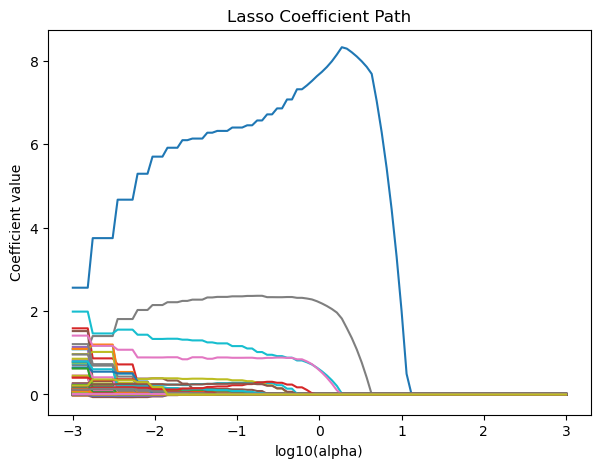

In [6]:
# --- Q3: Regularised Regression ---
df3 = pd.read_csv('data/train_house.csv')
y3 = np.log1p(df3['SalePrice'])
X3 = df3.drop(columns=['SalePrice', 'Id'])

missing_frac = X3.isna().mean()
X3 = X3.drop(columns=missing_frac[missing_frac > 0.40].index)

num_cols = X3.select_dtypes(include=[np.number]).columns
cat_cols = X3.select_dtypes(exclude=[np.number]).columns
for c in num_cols:
    X3[c] = X3[c].fillna(X3[c].median())
for c in cat_cols:
    X3[c] = X3[c].fillna(X3[c].mode()[0])

# cast numeric columns to float up front so the later scaled assignment doesn't
# hit pandas' "incompatible dtype" FutureWarning (int64 column <- float values)
X3[num_cols] = X3[num_cols].astype(float)

X3 = pd.get_dummies(X3, columns=cat_cols, drop_first=True)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.20, random_state=RANDOM_STATE)
X3_train = X3_train.copy()
X3_test = X3_test.copy()

scaler3 = StandardScaler().fit(X3_train[num_cols])
X3_train[num_cols] = pd.DataFrame(scaler3.transform(X3_train[num_cols]), columns=num_cols, index=X3_train.index)
X3_test[num_cols] = pd.DataFrame(scaler3.transform(X3_test[num_cols]), columns=num_cols, index=X3_test.index)

alphas3 = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas3, cv=5).fit(X3_train, y3_train)
lasso = LassoCV(alphas=alphas3, cv=5, max_iter=20000, random_state=RANDOM_STATE).fit(X3_train, y3_train)
enet = ElasticNetCV(alphas=alphas3, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0], cv=5,
                     max_iter=20000, random_state=RANDOM_STATE).fit(X3_train, y3_train)

def report(model, name):
    pred_log = model.predict(X3_test)
    rmse = np.sqrt(np.mean((np.expm1(pred_log) - np.expm1(y3_test)) ** 2))
    r2 = model.score(X3_test, y3_test)
    nz = np.sum(np.abs(model.coef_) > 1e-6)
    alpha = getattr(model, 'alpha_', None)
    print(f'{name}: alpha*={alpha}, nonzero_coefs={nz}, RMSE={rmse:.2f}, R2={r2:.4f}')
    return {'Model': name, 'alpha*': alpha, 'Nonzero coefs': nz, 'RMSE': rmse, 'R2': r2}

results3 = pd.DataFrame([report(ridge, 'Ridge'), report(lasso, 'Lasso'), report(enet, 'ElasticNet')])
print(results3)

# Lasso coefficient path
from sklearn.linear_model import lasso_path
alphas_path, coefs_path, _ = lasso_path(X3_train, y3_train, alphas=np.logspace(3, -3, 100))
plt.figure(figsize=(7, 5))
for i in range(coefs_path.shape[0]):
    plt.plot(np.log10(alphas_path), coefs_path[i])
plt.xlabel('log10(alpha)'); plt.ylabel('Coefficient value'); plt.title('Lasso Coefficient Path')
plt.show()
# --> annotate last 5 features to hit zero, and write 3-4 sentence geometric explanation

## 2.2 Locally Weighted Regression — California Housing [Medium]
**Goal:** from-scratch LWR (NumPy only), bandwidth sweep, compare to OLS.


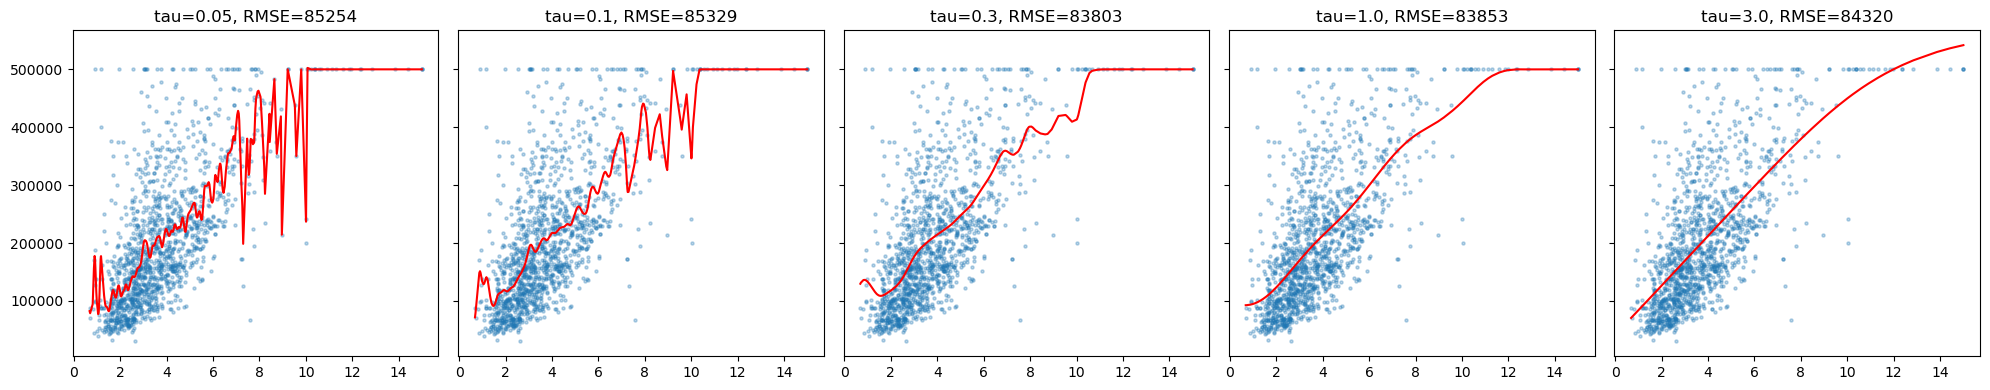

Best tau: 0.3 RMSE table: {0.05: np.float64(85254.28659701861), 0.1: np.float64(85328.6050312848), 0.3: np.float64(83802.65314614441), 1.0: np.float64(83853.05075584106), 3.0: np.float64(84320.29349532536)}
OLS RMSE: 85304.41746282301 | Best LWR RMSE: 83802.65314614441


In [7]:
# --- Q4: Locally Weighted Regression (from scratch) ---
df4 = pd.read_csv('data/housing.csv')
df4_sample = df4.sample(2000, random_state=RANDOM_STATE)
x4 = df4_sample['median_income'].values
y4 = df4_sample['median_house_value'].values

x4_train, x4_test, y4_train, y4_test = train_test_split(x4, y4, test_size=0.30, random_state=RANDOM_STATE)

def lwr_predict(x_train, y_train, x_query, tau):
    X = np.column_stack([np.ones_like(x_train), x_train])
    preds = np.zeros_like(x_query, dtype=float)
    for i, xq in enumerate(x_query):
        w = np.exp(-((x_train - xq) ** 2) / (2 * tau ** 2))
        W = np.diag(w)
        theta = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y_train
        preds[i] = theta[0] + theta[1] * xq
    return preds

taus = [0.05, 0.1, 0.3, 1.0, 3.0]
rmse_by_tau = {}
xs_sorted = np.sort(x4_train)
fig, axes = plt.subplots(1, len(taus), figsize=(20, 4), sharey=True)
for ax, tau in zip(axes, taus):
    fit_curve = lwr_predict(x4_train, y4_train, xs_sorted, tau)
    test_pred = lwr_predict(x4_train, y4_train, x4_test, tau)
    rmse = np.sqrt(np.mean((test_pred - y4_test) ** 2))
    rmse_by_tau[tau] = rmse
    ax.scatter(x4_train, y4_train, s=5, alpha=0.3)
    ax.plot(xs_sorted, fit_curve, color='red')
    ax.set_title(f'tau={tau}, RMSE={rmse:.0f}')
plt.tight_layout(); plt.show()

best_tau = min(rmse_by_tau, key=rmse_by_tau.get)
print('Best tau:', best_tau, 'RMSE table:', rmse_by_tau)

ols4 = LinearRegression().fit(x4_train.reshape(-1, 1), y4_train)
ols_rmse = np.sqrt(np.mean((ols4.predict(x4_test.reshape(-1, 1)) - y4_test) ** 2))
print('OLS RMSE:', ols_rmse, '| Best LWR RMSE:', rmse_by_tau[best_tau])
# As tau -> infinity, weights w_i -> 1 for all i, so weighted least squares reduces to OLS.


## 3.1 Random Forest — Fraud Detection [Hard]
**Goal:** OOB score, tune `max_features`, MDI vs Permutation Importance, AUC-ROC/AUC-PR, OOB curve.


OOB score: 0.9723714285714286
{'sqrt': np.float64(0.8784050049616322), 'log2': np.float64(0.8719641511004432), 0.3: np.float64(0.8762381795975085), 0.5: np.float64(0.8780703530521565)}


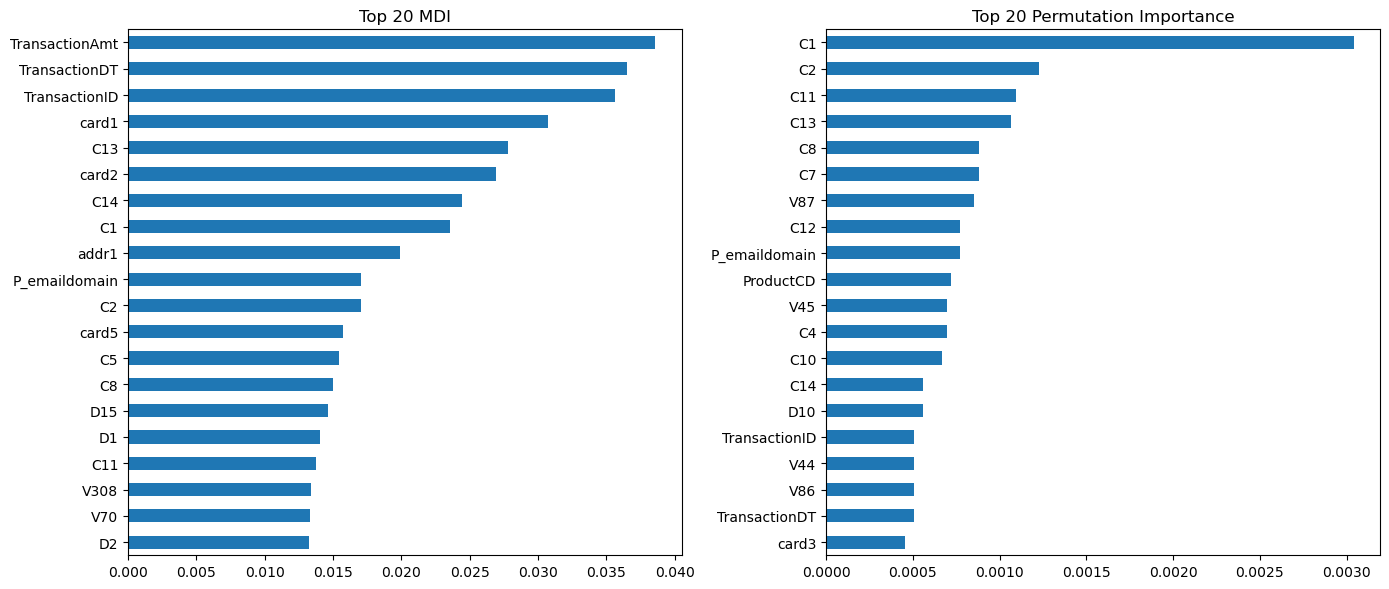

Test AUC-ROC: 0.8877620056972791


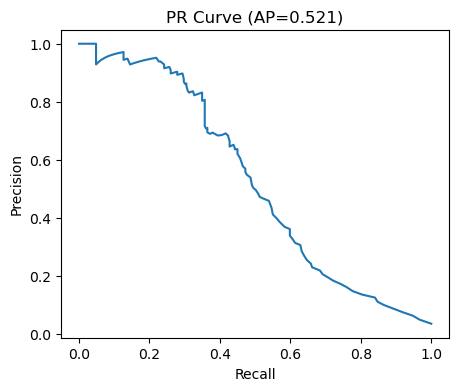

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


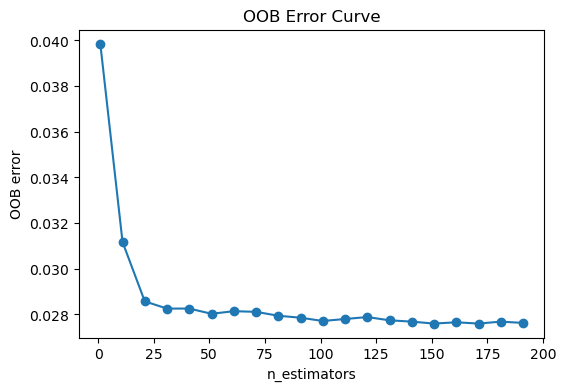

[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:   17.3s remaining:    8.6s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:   27.9s remaining:    3.5s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:   35.1s finished
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done  10 out of  20 | elapsed:   20.1s remaining:   20.1s
[Parallel(n_jobs=-1)]: Done  15 out of  20 | elapsed:   20.3s remaining:    6.8s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:   26.6s finished


In [8]:
# --- Q5: Random Forest Fraud Detection ---
df5 = pd.read_csv('data/train_transaction.csv')
df5 = df5.sample(50000, random_state=RANDOM_STATE)

missing_frac5 = df5.isna().mean()
df5 = df5.drop(columns=missing_frac5[missing_frac5 > 0.50].index)

y5 = df5['isFraud']
X5 = df5.drop(columns=['isFraud'])
cat_cols5 = X5.select_dtypes(include=['object']).columns
for c in cat_cols5:
    X5[c] = X5[c].astype('category').cat.codes
X5 = X5.fillna(X5.median(numeric_only=True))

X5_train, X5_temp, y5_train, y5_temp = train_test_split(X5, y5, test_size=0.30, stratify=y5, random_state=RANDOM_STATE)
X5_val, X5_test, y5_val, y5_test = train_test_split(X5_temp, y5_temp, test_size=0.50, stratify=y5_temp, random_state=RANDOM_STATE)

rf5 = RandomForestClassifier(n_estimators=200, oob_score=True, class_weight='balanced',
                              random_state=RANDOM_STATE, n_jobs=-1).fit(X5_train, y5_train)
print('OOB score:', rf5.oob_score_)

mf_grid = ['sqrt', 'log2', 0.3, 0.5]
mf_scores = {}
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for mf in mf_grid:
    m = RandomForestClassifier(n_estimators=200, max_features=mf, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1)
    scores = cross_val_score(m, X5_train, y5_train, cv=skf5, scoring='roc_auc')
    mf_scores[mf] = scores.mean()
print(mf_scores)
best_mf = max(mf_scores, key=mf_scores.get)

best_rf5 = RandomForestClassifier(n_estimators=200, max_features=best_mf, oob_score=True,
                                   class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
best_rf5.fit(X5_train, y5_train)

mdi = pd.Series(best_rf5.feature_importances_, index=X5.columns).sort_values(ascending=False).head(20)
perm = permutation_importance(best_rf5, X5_val, y5_val, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X5.columns).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
mdi.plot(kind='barh', ax=axes[0], title='Top 20 MDI'); axes[0].invert_yaxis()
perm_imp.plot(kind='barh', ax=axes[1], title='Top 20 Permutation Importance'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()
# --> discuss MDI's known bias toward high-cardinality features vs permutation importance

y5_proba = best_rf5.predict_proba(X5_test)[:, 1]
print('Test AUC-ROC:', roc_auc_score(y5_test, y5_proba))
prec5, rec5, _ = precision_recall_curve(y5_test, y5_proba)
ap5 = average_precision_score(y5_test, y5_proba)
plt.figure(figsize=(5, 4)); plt.plot(rec5, prec5); plt.title(f'PR Curve (AP={ap5:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.show()
# AUC-PR is more informative than AUC-ROC under class imbalance because it focuses on
# performance on the minority (positive) class rather than being inflated by the
# large number of easy true negatives.

# OOB error vs n_estimators
oob_errors = []
n_range = range(1, 201, 10)
for n in n_range:
    m = RandomForestClassifier(n_estimators=n, oob_score=True, max_features=best_mf,
                                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, warm_start=False)
    m.fit(X5_train, y5_train)
    oob_errors.append(1 - m.oob_score_)
plt.figure(figsize=(6, 4)); plt.plot(list(n_range), oob_errors, marker='o')
plt.xlabel('n_estimators'); plt.ylabel('OOB error'); plt.title('OOB Error Curve'); plt.show()


## 3.2 XGBoost — Stock Return Classification [Hard]
**Goal:** engineered features, mandatory time-based split, manual grid search, feature importance.


/var/folders/n7/96zdhb2s72sd10bjjnwvrdw00000gn/T/ipykernel_13679/66348826.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df6 = df6.groupby('Name', group_keys=False).apply(engineer_features).dropna()


    max_depth  learning_rate  subsample   val_auc
11          5           0.10        0.8  0.525851
5           3           0.10        0.8  0.525538
7           5           0.01        0.8  0.525415
9           5           0.05        0.8  0.525325
2           3           0.05        0.6  0.525227
Best params (depth, lr, subsample): (5, 0.1, 0.8)
Test AUC-ROC: 0.49420157199442494 | AUC-PR: 0.6131016241028746 | Majority baseline acc: 0.6183056918165538


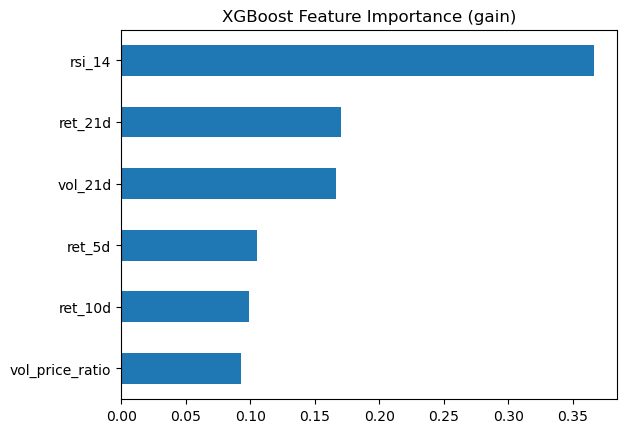

'\nRandom k-fold CV is invalid for financial time series because shuffling breaks\ntemporal ordering: a model can be trained on data from *after* the test point and\nevaluated on data from *before* it. Rolling/lagged features (e.g. 21-day returns)\ncomputed near fold boundaries leak future price information into training folds.\nThis look-ahead bias lets the model "see the future" during fitting, so it learns\nspurious patterns that exploit the leakage rather than genuine predictive signal.\nThe resulting validation AUC is therefore systematically inflated relative to what\nthe model would achieve in live, causally-ordered deployment, which is why only a\nstrict expanding/rolling time-based split is valid here.\n'

In [9]:
# --- Q6: XGBoost Stock Return Classification ---
df6 = pd.read_csv('data/all_stocks_5yr.csv', parse_dates=['date'])

def engineer_features(g):
    g = g.sort_values('date').copy()
    g['ret_5d'] = g['close'].pct_change(5)
    g['ret_10d'] = g['close'].pct_change(10)
    g['ret_21d'] = g['close'].pct_change(21)
    g['vol_21d'] = g['close'].pct_change().rolling(21).std()
    g['vol_price_ratio'] = g['volume'] / g['close']
    delta = g['close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    g['rsi_14'] = 100 - 100 / (1 + rs)
    g['fwd_ret_21d'] = g['close'].shift(-21) / g['close'] - 1
    g['target'] = (g['fwd_ret_21d'] > 0).astype(int)
    return g

df6 = df6.groupby('Name', group_keys=False).apply(engineer_features).dropna()

feature_cols6 = ['ret_5d', 'ret_10d', 'ret_21d', 'vol_21d', 'vol_price_ratio', 'rsi_14']
train6 = df6[df6['date'] < '2017-01-01']
test6 = df6[df6['date'] >= '2017-01-01']

eval_cutoff = train6['date'].max() - pd.Timedelta(days=183)
fit6 = train6[train6['date'] < eval_cutoff]
es6 = train6[train6['date'] >= eval_cutoff]

X6_train, y6_train = fit6[feature_cols6], fit6['target']
X6_es, y6_es = es6[feature_cols6], es6['target']
X6_test, y6_test = test6[feature_cols6], test6['target']

grid6 = {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.6, 0.8]}
best_auc6, best_params6, best_model6 = -1, None, None
results6 = []
for d in grid6['max_depth']:
    for lr in grid6['learning_rate']:
        for ss in grid6['subsample']:
            model = xgb.XGBClassifier(max_depth=d, learning_rate=lr, subsample=ss,
                                       n_estimators=500, eval_metric='auc',
                                       early_stopping_rounds=20, random_state=RANDOM_STATE)
            model.fit(X6_train, y6_train, eval_set=[(X6_es, y6_es)], verbose=False)
            val_auc = roc_auc_score(y6_es, model.predict_proba(X6_es)[:, 1])
            results6.append({'max_depth': d, 'learning_rate': lr, 'subsample': ss, 'val_auc': val_auc})
            if val_auc > best_auc6:
                best_auc6, best_params6, best_model6 = val_auc, (d, lr, ss), model

results6_df = pd.DataFrame(results6).sort_values('val_auc', ascending=False)
print(results6_df.head())
print('Best params (depth, lr, subsample):', best_params6)

y6_proba = best_model6.predict_proba(X6_test)[:, 1]
auc_roc6 = roc_auc_score(y6_test, y6_proba)
ap6 = average_precision_score(y6_test, y6_proba)
baseline6 = max(y6_test.mean(), 1 - y6_test.mean())
print('Test AUC-ROC:', auc_roc6, '| AUC-PR:', ap6, '| Majority baseline acc:', baseline6)

imp6 = pd.Series(best_model6.feature_importances_, index=feature_cols6).sort_values(ascending=False)
imp6.plot(kind='barh', title='XGBoost Feature Importance (gain)'); plt.gca().invert_yaxis(); plt.show()
# --> economic interpretation of the top feature

"""
Random k-fold CV is invalid for financial time series because shuffling breaks
temporal ordering: a model can be trained on data from *after* the test point and
evaluated on data from *before* it. Rolling/lagged features (e.g. 21-day returns)
computed near fold boundaries leak future price information into training folds.
This look-ahead bias lets the model "see the future" during fitting, so it learns
spurious patterns that exploit the leakage rather than genuine predictive signal.
The resulting validation AUC is therefore systematically inflated relative to what
the model would achieve in live, causally-ordered deployment, which is why only a
strict expanding/rolling time-based split is valid here.
"""


## 4.1 Empirical Bias-Variance Decomposition [Medium]
**Goal:** bootstrap (B=50) bias²/variance for 5 models of increasing complexity.


                 Model    Bias^2       Var  Bias^2+Var  Test AUC-ROC
0  Logistic Regression  0.173832  0.003637    0.177469      0.796523
1       Decision Stump  0.189764  0.013964    0.203728      0.629015
2        Unpruned Tree  0.173967  0.144821    0.318788      0.698055
3        Random Forest  0.168497  0.006760    0.175257      0.803974
4              XGBoost  0.193781  0.031391    0.225172      0.782285


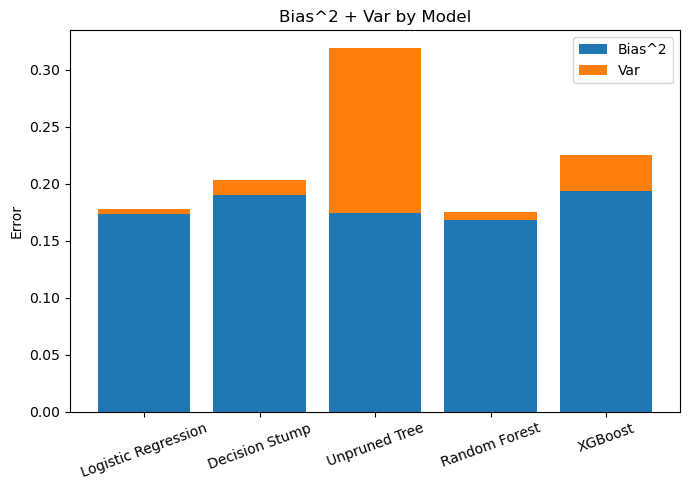

"\nBagging (Random Forest) averages B trees trained on bootstrap samples whose\npredictions have pairwise correlation rho; the ensemble variance is\nrho*sigma^2 + (1-rho)/B * sigma^2. As B grows the second term vanishes, leaving\nrho*sigma^2 — variance shrinks but never below the irreducible correlated part,\nand since each tree is trained on a sample from the same distribution with no\nadjustment for residual error, average bias stays close to a single deep tree's\nbias. Boosting (XGBoost) instead fits each new tree to the residual/gradient of\nthe current ensemble, sequentially correcting systematic errors, which reduces\nbias directly; the shrinkage (learning_rate) and subsampling also control\nvariance, so boosting can reduce both bias and variance simultaneously, though it\nis more prone to overfitting variance if not regularised.\n"

In [10]:
# --- Q7: Bias-Variance Decomposition ---
df7 = pd.read_csv('data/diabetes.csv')
X7 = df7.drop(columns=['Outcome']).values
y7 = df7['Outcome'].values

X7_train, X7_test, y7_train, y7_test = train_test_split(X7, y7, test_size=0.30, random_state=RANDOM_STATE)

models7 = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000),
    'Decision Stump': lambda: DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    'Unpruned Tree': lambda: DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': lambda: xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

B = 50
n_train = len(X7_train)
summary7 = []
for name, ctor in models7.items():
    preds = np.zeros((B, len(X7_test)))
    rng = np.random.RandomState(RANDOM_STATE)
    for b in range(B):
        idx = rng.choice(n_train, n_train, replace=True)
        m = ctor().fit(X7_train[idx], y7_train[idx])
        preds[b] = m.predict_proba(X7_test)[:, 1]
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - y7_test) ** 2)
    var = np.mean(preds.var(axis=0))
    full_model = ctor().fit(X7_train, y7_train)
    auc = roc_auc_score(y7_test, full_model.predict_proba(X7_test)[:, 1])
    summary7.append({'Model': name, 'Bias^2': bias2, 'Var': var, 'Bias^2+Var': bias2 + var, 'Test AUC-ROC': auc})

summary7_df = pd.DataFrame(summary7)
print(summary7_df)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(summary7_df['Model'], summary7_df['Bias^2'], label='Bias^2')
ax.bar(summary7_df['Model'], summary7_df['Var'], bottom=summary7_df['Bias^2'], label='Var')
plt.xticks(rotation=20); plt.ylabel('Error'); plt.legend(); plt.title('Bias^2 + Var by Model')
plt.tight_layout(); plt.show()

"""
Bagging (Random Forest) averages B trees trained on bootstrap samples whose
predictions have pairwise correlation rho; the ensemble variance is
rho*sigma^2 + (1-rho)/B * sigma^2. As B grows the second term vanishes, leaving
rho*sigma^2 — variance shrinks but never below the irreducible correlated part,
and since each tree is trained on a sample from the same distribution with no
adjustment for residual error, average bias stays close to a single deep tree's
bias. Boosting (XGBoost) instead fits each new tree to the residual/gradient of
the current ensemble, sequentially correcting systematic errors, which reduces
bias directly; the shrinkage (learning_rate) and subsampling also control
variance, so boosting can reduce both bias and variance simultaneously, though it
is more prone to overfitting variance if not regularised.
"""


## 5.1 Gradient Boosting with Uncertainty Estimation [Hard]
**Goal:** expanding-window CV tuning, top-5 feature selection, ensemble-disagreement
uncertainty (σᵢ), illustrative long-short backtest.


## Bonus: Stacked Generalisation — Titanic [Hard / Optional]
**Goal:** 5 base learners with out-of-fold (OOF) predictions feeding a logistic-regression meta-learner.


/var/folders/n7/96zdhb2s72sd10bjjnwvrdw00000gn/T/ipykernel_13679/1188499345.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Symbol", group_keys=False).apply(engineer_features)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Running grid search over 27 configs x 3 folds (parallel across CPU cores)...
Grid search finished in 36.2s
Expanding-window CV results (top 10):
 n_estimators  max_depth  learning_rate  mean_auc
          500          5           0.05  0.497639
          100          5           0.01  0.497573
          500          5           0.10  0.497487
          500          2           0.10  0.497381
          500          3           0.05  0.497346
          500          2           0.05  0.497339
          100          5           0.05  0.497041
          500          3           0.10  0.496940
          200          3           0.10  0.496937
          100          3           0.10  0.496762

Best hyperparameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}

Full-model test AUC-ROC: 0.5133

Permutation importance ranking:
        feature  importance_mean
        vol_21d         0.009497
        ret_63d         0.008357
 pct_of_52w_low         0.001323
         ret_5d        

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Bootstrap ensemble finished in 27.6s


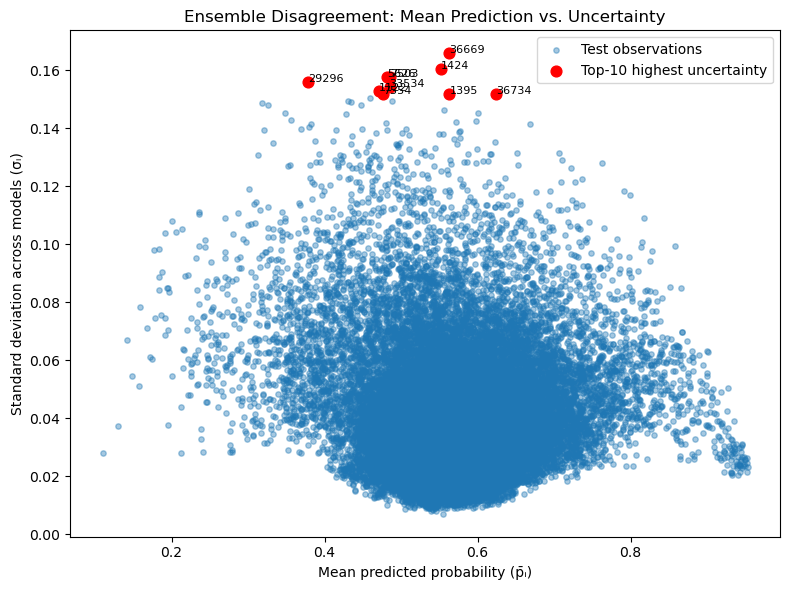

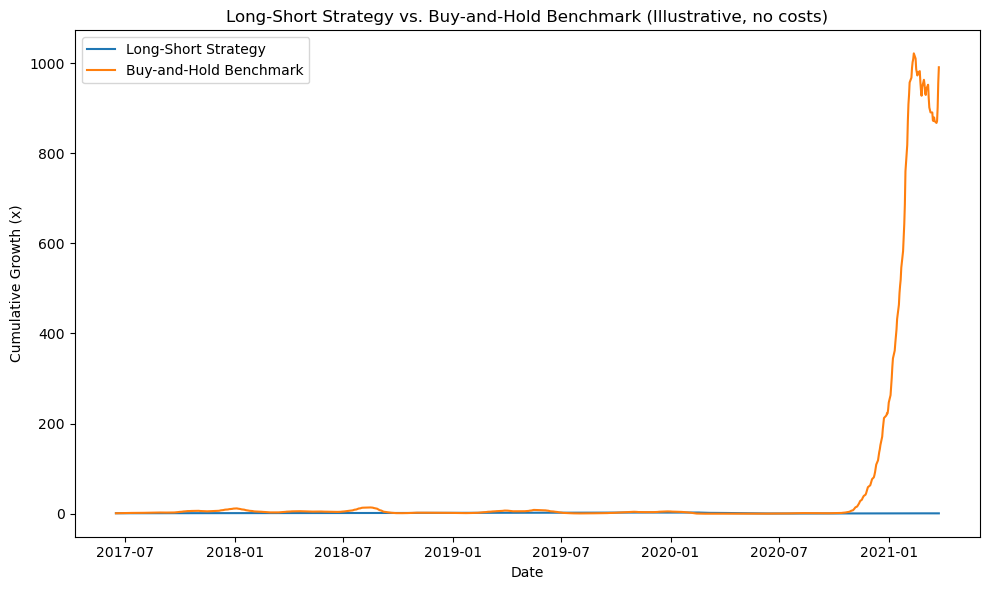


--- Summary ---
Best hyperparameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}
Full model test AUC-ROC: 0.5133
Top-5-feature model test AUC-ROC: 0.5311
Top 5 features: ['vol_21d', 'ret_63d', 'pct_of_52w_low', 'ret_5d', 'volume_zscore']


In [11]:
# ============================================================
# Q5.1 — Gradient Boosting with Uncertainty Estimation for Return Prediction
# Dataset: NIFTY-50 Stock Market (2000-2021) -> NIFTY50_all.csv
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier  # much faster than GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from joblib import Parallel, delayed

RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)


def make_gb(random_state, n_estimators, max_depth, learning_rate):
    """Thin wrapper so the rest of the script can still talk in terms of
    n_estimators / max_depth, while actually using the much faster
    HistGradientBoostingClassifier under the hood (n_estimators -> max_iter)."""
    return HistGradientBoostingClassifier(
        max_iter=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=random_state,
    )

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------
df = pd.read_csv("data/NIFTY50_all.csv", parse_dates=["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Feature engineering (per stock)
# ------------------------------------------------------------
def engineer_features(g):
    g = g.copy()
    g["ret_1d"] = g["Close"].pct_change()

    g["ret_5d"] = g["Close"].pct_change(5)
    g["ret_21d"] = g["Close"].pct_change(21)
    g["ret_63d"] = g["Close"].pct_change(63)

    g["vol_21d"] = g["ret_1d"].rolling(21).std()
    g["vol_63d"] = g["ret_1d"].rolling(63).std()

    g["high_252d"] = g["Close"].rolling(252, min_periods=50).max()
    g["low_252d"] = g["Close"].rolling(252, min_periods=50).min()
    g["pct_of_52w_high"] = g["Close"] / g["high_252d"]
    g["pct_of_52w_low"] = g["Close"] / g["low_252d"]

    vol_mean_21 = g["Volume"].rolling(21).mean()
    vol_std_21 = g["Volume"].rolling(21).std()
    g["volume_zscore"] = (g["Volume"] - vol_mean_21) / vol_std_21

    # forward 21-day return -> binary target
    fwd_ret = g["Close"].shift(-21) / g["Close"] - 1
    g["target"] = (fwd_ret > 0).astype(int)
    g["fwd_ret"] = fwd_ret  # kept for the long-short backtest later

    return g

df = df.groupby("Symbol", group_keys=False).apply(engineer_features)

FEATURE_COLS = [
    "ret_5d", "ret_21d", "ret_63d",
    "vol_21d", "vol_63d",
    "pct_of_52w_high", "pct_of_52w_low",
    "volume_zscore",
]

df_model = df.dropna(subset=FEATURE_COLS + ["target", "fwd_ret"]).reset_index(drop=True)
df_model = df_model.sort_values("Date").reset_index(drop=True)

X = df_model[FEATURE_COLS].values
y = df_model["target"].values
dates = df_model["Date"].values

# ------------------------------------------------------------
# 3. Expanding-window time-series CV hyperparameter tuning
# ------------------------------------------------------------
param_grid = [
    {"n_estimators": n, "max_depth": d, "learning_rate": lr}
    for n in [100, 200, 500]
    for d in [2, 3, 5]
    for lr in [0.01, 0.05, 0.1]
]

tscv = TimeSeriesSplit(n_splits=3)


def evaluate_params(params):
    fold_aucs = []
    for train_idx, val_idx in tscv.split(X):
        model = make_gb(RANDOM_STATE, **params)
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict_proba(X[val_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y[val_idx], preds))
    return {**params, "mean_auc": np.mean(fold_aucs)}


print(f"Running grid search over {len(param_grid)} configs x 3 folds "
      f"(parallel across CPU cores)...")
t0 = time.time()
cv_results = Parallel(n_jobs=-1, verbose=5)(
    delayed(evaluate_params)(params) for params in param_grid
)
print(f"Grid search finished in {time.time() - t0:.1f}s")

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_auc", ascending=False)
print("Expanding-window CV results (top 10):")
print(cv_results_df.head(10).to_string(index=False))

best_params = cv_results_df.iloc[0][["n_estimators", "max_depth", "learning_rate"]].to_dict()
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
print("\nBest hyperparameters:", best_params)

# ------------------------------------------------------------
# Final chronological train/test split for evaluation
# (last fold of the expanding-window scheme acts as the held-out test set)
# ------------------------------------------------------------
n = len(X)
split_idx = int(n * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

best_model = make_gb(RANDOM_STATE, **best_params)
best_model.fit(X_train, y_train)
full_test_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
print(f"\nFull-model test AUC-ROC: {full_test_auc:.4f}")

# ------------------------------------------------------------
# 4. Feature selection via permutation importance -> top 5 features
# ------------------------------------------------------------
perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE
)
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance_mean": perm_result.importances_mean,
}).sort_values("importance_mean", ascending=False)
print("\nPermutation importance ranking:")
print(importance_df.to_string(index=False))

top5_features = importance_df["feature"].head(5).tolist()
top5_idx = [FEATURE_COLS.index(f) for f in top5_features]

X_train_top5 = X_train[:, top5_idx]
X_test_top5 = X_test[:, top5_idx]

model_top5 = make_gb(RANDOM_STATE, **best_params)
model_top5.fit(X_train_top5, y_train)
top5_test_auc = roc_auc_score(y_test, model_top5.predict_proba(X_test_top5)[:, 1])

print(f"\nTop-5-feature model test AUC-ROC: {top5_test_auc:.4f}")
print(f"Full model test AUC-ROC:          {full_test_auc:.4f}")

# ------------------------------------------------------------
# 5. Uncertainty estimation via ensemble disagreement (M = 20 bootstraps)
# ------------------------------------------------------------
M = 20
n_train = len(X_train)


def fit_bootstrap_model(m):
    # each worker gets its own RNG seeded off m, so bootstrap samples differ per model
    local_rng = np.random.RandomState(RANDOM_STATE + m)
    boot_idx = local_rng.choice(n_train, size=n_train, replace=True)
    model_m = make_gb(RANDOM_STATE + m, **best_params)
    model_m.fit(X_train[boot_idx], y_train[boot_idx])
    return model_m.predict_proba(X_test)[:, 1]


print(f"Training {M} bootstrap models for uncertainty estimation (parallel)...")
t0 = time.time()
bootstrap_results = Parallel(n_jobs=-1, verbose=5)(
    delayed(fit_bootstrap_model)(m) for m in range(M)
)
print(f"Bootstrap ensemble finished in {time.time() - t0:.1f}s")

all_test_probs = np.vstack(bootstrap_results)

p_mean = all_test_probs.mean(axis=0)
p_std = all_test_probs.std(axis=0)

top_uncertain_idx = np.argsort(p_std)[-10:]

plt.figure(figsize=(8, 6))
plt.scatter(p_mean, p_std, alpha=0.4, s=15, label="Test observations")
plt.scatter(p_mean[top_uncertain_idx], p_std[top_uncertain_idx],
            color="red", s=60, label="Top-10 highest uncertainty")
for idx in top_uncertain_idx:
    plt.annotate(str(idx), (p_mean[idx], p_std[idx]), fontsize=8)
plt.xlabel("Mean predicted probability (p̄ᵢ)")
plt.ylabel("Standard deviation across models (σᵢ)")
plt.title("Ensemble Disagreement: Mean Prediction vs. Uncertainty")
plt.legend()
plt.tight_layout()
plt.savefig("uncertainty_scatter.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# 6. Simple long-short strategy (illustrative only)
# ------------------------------------------------------------
# Disclaimer: illustrative only — ignores transaction costs, slippage, market impact.
test_df = df_model.iloc[split_idx:].copy().reset_index(drop=True)
test_df["p_mean"] = p_mean

decile_top = test_df["p_mean"].quantile(0.9)
decile_bottom = test_df["p_mean"].quantile(0.1)

test_df["position"] = 0
test_df.loc[test_df["p_mean"] >= decile_top, "position"] = 1
test_df.loc[test_df["p_mean"] <= decile_bottom, "position"] = -1

test_df["strategy_ret"] = test_df["position"] * test_df["fwd_ret"]

strategy_by_date = test_df.groupby("Date")["strategy_ret"].mean().sort_index()
strategy_cum = (1 + strategy_by_date.fillna(0)).cumprod()

benchmark_by_date = test_df.groupby("Date")["fwd_ret"].mean().sort_index()
benchmark_cum = (1 + benchmark_by_date.fillna(0)).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(strategy_cum.index, strategy_cum.values, label="Long-Short Strategy")
plt.plot(benchmark_cum.index, benchmark_cum.values, label="Buy-and-Hold Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (x)")
plt.title("Long-Short Strategy vs. Buy-and-Hold Benchmark (Illustrative, no costs)")
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_returns.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# Summary printout
# ------------------------------------------------------------
print("\n--- Summary ---")
print(f"Best hyperparameters: {best_params}")
print(f"Full model test AUC-ROC: {full_test_auc:.4f}")
print(f"Top-5-feature model test AUC-ROC: {top5_test_auc:.4f}")
print(f"Top 5 features: {top5_features}")

Base learners vs. Stacked Ensemble (holdout set):
             Model  AUC-ROC  Accuracy
  Stacked Ensemble 0.847299  0.804469
               KNN 0.844664  0.798883
LogisticRegression 0.838735  0.798883
      RandomForest 0.833333  0.804469
           XGBoost 0.808959  0.804469
      DecisionTree 0.801779  0.759777


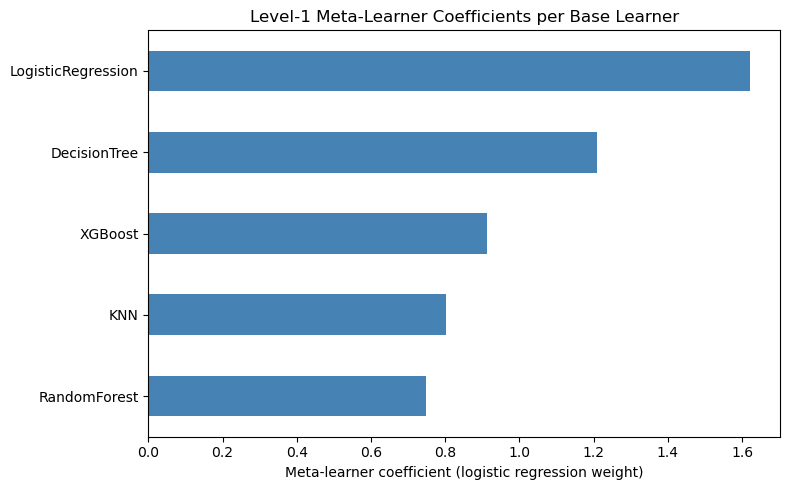


Meta-learner coefficients (sorted):
LogisticRegression    1.621084
DecisionTree          1.209838
XGBoost               0.912257
KNN                   0.802418
RandomForest          0.747649

Base learner with highest meta-learner weight: LogisticRegression
AUC-ROC ranking for comparison:
             Model  AUC-ROC
  Stacked Ensemble 0.847299
               KNN 0.844664
LogisticRegression 0.838735
      RandomForest 0.833333
           XGBoost 0.808959
      DecisionTree 0.801779

Saved submission.csv for Kaggle leaderboard upload.


In [14]:
# ============================================================
# Bonus - Stacked Generalisation for Titanic Survival Prediction
# Dataset: Titanic - Machine Learning from Disaster (train.csv, test.csv)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# ------------------------------------------------------------
# 1. Load data + feature engineering
# ------------------------------------------------------------
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")  # official Kaggle test (no labels)


def engineer(df):
    df = df.copy()
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    df = pd.get_dummies(df, columns=["Embarked"], prefix="Emb")
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    keep = ["Pclass", "Sex", "Age", "Fare", "FamilySize"] + \
           [c for c in df.columns if c.startswith("Emb_")]
    return df[keep]


X_full = engineer(train_raw)
y_full = train_raw["Survived"].values
X_kaggle_test = engineer(test_raw)

for col in X_full.columns:
    if col not in X_kaggle_test.columns:
        X_kaggle_test[col] = 0
X_kaggle_test = X_kaggle_test[X_full.columns]

# Local labelled holdout (Kaggle's test.csv has no Survived labels,
# so a holdout is carved out of train.csv for evaluation)
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)
X_kaggle_test_scaled = scaler.transform(X_kaggle_test)

X_train_np = X_train.values
X_holdout_np = X_holdout.values
X_kaggle_test_np = X_kaggle_test.values

# ------------------------------------------------------------
# 2. Level-0 base learners
# ------------------------------------------------------------
base_learners = {
    "LogisticRegression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    "DecisionTree": (DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), False),
    "RandomForest": (RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), False),
    "XGBoost": (XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=RANDOM_STATE), False),
    "KNN": (KNeighborsClassifier(n_neighbors=5), True),
}

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

n_train = X_train_np.shape[0]
oof_preds = pd.DataFrame(index=range(n_train), columns=base_learners.keys(), dtype=float)
holdout_preds = pd.DataFrame(index=range(len(X_holdout_np)), columns=base_learners.keys(), dtype=float)
kaggle_test_preds = pd.DataFrame(index=range(len(X_kaggle_test_np)), columns=base_learners.keys(), dtype=float)

individual_auc = {}
individual_acc = {}

for name, (model_template, needs_scaling) in base_learners.items():
    Xtr_full = X_train_scaled if needs_scaling else X_train_np
    Xho_full = X_holdout_scaled if needs_scaling else X_holdout_np
    Xkt_full = X_kaggle_test_scaled if needs_scaling else X_kaggle_test_np

    oof_col = np.zeros(n_train)

    # out-of-fold predictions on the training set -> meta-features
    for tr_idx, val_idx in kf.split(Xtr_full):
        model = type(model_template)(**model_template.get_params())
        model.fit(Xtr_full[tr_idx], y_train[tr_idx])
        oof_col[val_idx] = model.predict_proba(Xtr_full[val_idx])[:, 1]

    oof_preds[name] = oof_col

    # refit on full training data -> predict holdout + kaggle test
    full_model = type(model_template)(**model_template.get_params())
    full_model.fit(Xtr_full, y_train)
    holdout_preds[name] = full_model.predict_proba(Xho_full)[:, 1]
    kaggle_test_preds[name] = full_model.predict_proba(Xkt_full)[:, 1]

    ho_prob = holdout_preds[name].values
    individual_auc[name] = roc_auc_score(y_holdout, ho_prob)
    individual_acc[name] = accuracy_score(y_holdout, (ho_prob >= 0.5).astype(int))

# ------------------------------------------------------------
# 3. Level-1 meta-learner (Logistic Regression on OOF predictions)
# ------------------------------------------------------------
meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
meta_model.fit(oof_preds.values, y_train)

meta_holdout_prob = meta_model.predict_proba(holdout_preds.values)[:, 1]
meta_holdout_pred = (meta_holdout_prob >= 0.5).astype(int)

stack_auc = roc_auc_score(y_holdout, meta_holdout_prob)
stack_acc = accuracy_score(y_holdout, meta_holdout_pred)

# ------------------------------------------------------------
# 4. Comparison table
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Model": list(individual_auc.keys()) + ["Stacked Ensemble"],
    "AUC-ROC": list(individual_auc.values()) + [stack_auc],
    "Accuracy": list(individual_acc.values()) + [stack_acc],
}).sort_values("AUC-ROC", ascending=False)

print("Base learners vs. Stacked Ensemble (holdout set):")
print(comparison.to_string(index=False))

# ------------------------------------------------------------
# 5. Meta-learner coefficient plot
# ------------------------------------------------------------
coefs = pd.Series(meta_model.coef_[0], index=oof_preds.columns).sort_values()

plt.figure(figsize=(8, 5))
coefs.plot(kind="barh", color="steelblue")
plt.xlabel("Meta-learner coefficient (logistic regression weight)")
plt.title("Level-1 Meta-Learner Coefficients per Base Learner")
plt.tight_layout()
plt.savefig("meta_learner_coefficients.png", dpi=150)
plt.show()

print("\nMeta-learner coefficients (sorted):")
print(coefs.sort_values(ascending=False).to_string())

highest_weight_model = coefs.idxmax()
print(f"\nBase learner with highest meta-learner weight: {highest_weight_model}")
print("AUC-ROC ranking for comparison:")
print(comparison.sort_values("AUC-ROC", ascending=False)[["Model", "AUC-ROC"]].to_string(index=False))

# ------------------------------------------------------------
# 6. Kaggle leaderboard submission file
# ------------------------------------------------------------
final_kaggle_prob = meta_model.predict_proba(kaggle_test_preds.values)[:, 1]
final_kaggle_pred = (final_kaggle_prob >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": final_kaggle_pred,
})
submission.to_csv("submission.csv", index=False)
print("\nSaved submission.csv for Kaggle leaderboard upload.")
# After uploading submission.csv to kaggle.com/c/titanic/submit, record the
# public leaderboard score here, e.g.:
# Kaggle public leaderboard score: 0.77990